In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from aquarel import load_theme
import numpy as np
import matplotlib as mpl
import matplotlib.patches as patches
from scipy.stats import ks_2samp
import itertools

theme = load_theme("minimal_light")
theme.apply()
theme.apply_transforms()
mpl.rcParams['axes.spines.left'] = True
mpl.rcParams['axes.spines.right'] = False
mpl.rcParams['axes.spines.top'] = False
mpl.rcParams['axes.spines.bottom'] = True
mpl.rcParams['axes.edgecolor'] = 'grey'

<Figure size 640x480 with 0 Axes>

In [ ]:
FIGURE_DATA = Path("../figure_data")

ES_INPUT_MAP = {'es0': 0, 'es1': 0.15, 'es2': 0.5, 'es3': 0.7, 'es4': 1, 'es5': 2}

v2_path = FIGURE_DATA / 'paramtraversal_v2.csv'
v1_path = FIGURE_DATA / 'paramtraversal.csv'

if v2_path.exists():
    pt_concat = pd.read_csv(v2_path)
    is_v2 = True
else:
    pt_concat = pd.read_csv(v1_path)
    pt_concat['Counting'] = 'JOINT'
    is_v2 = False

pt_concat = pt_concat[pt_concat['Threshold'].isin([0.01])]
pt_concat = pt_concat[pt_concat['Bonferroni'].isin(['fdr_by'])]

print(f"Loaded {'v2' if is_v2 else 'v1'} data: {pt_concat.shape}")
print('Methods:', sorted(pt_concat['Method'].unique()))
print('Statistics:', sorted(pt_concat['Statistic'].unique()))
print('Counting:', sorted(pt_concat['Counting'].unique()) if 'Counting' in pt_concat.columns else 'N/A')
if 'effect_size' in pt_concat.columns:
    print('Effect sizes:', sorted(pt_concat['effect_size'].unique()))
pt_concat.head()

In [ ]:
def _rename_method(orig):
    """Strip legacy 'simulate_glrates_' prefix for display labels."""
    prefix = 'simulate_glrates_'
    return orig[len(prefix):] if orig.startswith(prefix) else orig


def _clean_stat_name(s):
    """
    Normalise statistic column labels for display.
    Handles both v1-style ('_log_odds_ratio_statistic') and v2-style ('lor').
    """
    if s.endswith('_statistic'):
        s = s[:-10]          # strip '_statistic' suffix (10 chars)
    if s.startswith('_'):
        s = s[1:]            # strip leading underscore
    return s


def _plot_trav_single(df, metric, es_input, ascending=True,
                      highlight_bit_log_odds=True, ax=None):
    """
    Core heatmap for one (Method × Statistic) grid at a given es_input.

    Parameters
    ----------
    df     : DataFrame already filtered to the desired Counting method.
    ax     : matplotlib Axes to draw on; if None, creates a new figure.
    """
    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(4.5, 4.5))

    if 'es_input' in df.columns:
        df = df[df['es_input'] == es_input]

    piv = pd.pivot_table(df, index='Method', columns='Statistic', values=metric)

    orig_index   = list(piv.index)
    orig_columns = list(piv.columns)

    piv.index   = [_rename_method(i)    for i in orig_index]
    piv.columns = [_clean_stat_name(c)  for c in orig_columns]

    sns.heatmap(piv,
                cmap='Blues' if ascending else 'Blues_r',
                annot=True, fmt=".3f",
                cbar=False, cbar_kws={'ticks': []},
                square=True, ax=ax)

    if highlight_bit_log_odds:
        for method_key in ['bit', 'simulate']:
            for stat_key in ['log_odds_ratio', 'lor']:
                try:
                    y_pos = list(piv.index).index(method_key)
                    x_pos = list(piv.columns).index(stat_key)
                    ax.add_patch(patches.Rectangle(
                        (x_pos, y_pos), 1, 1,
                        linewidth=3, edgecolor='red', facecolor='none', clip_on=False))
                    break
                except ValueError:
                    continue
            else:
                continue
            break

    ax.set_ylabel('Simulation Method')
    ax.set_xlabel('Scoring Function')
    ax.set_title(metric.replace('_', ' '))

    if own_fig:
        plt.tight_layout()
        plt.show()


def plot_trav(pt_concat, metric, es_input, ascending=True,
              highlight_bit_log_odds=True, counting_method='both'):
    """
    Heatmap of a single metric over the (Method × Statistic) grid.

    Parameters
    ----------
    pt_concat         : DataFrame (may or may not have Counting column).
    metric            : str, column to visualise (e.g. 'PR_AUC_Positive').
    es_input          : float, effect-size value to filter on (e.g. 1.0 for es4).
    ascending         : bool, colour direction.
    highlight_bit_log_odds : bool, draw red rectangle on LOR/simulate cell.
    counting_method   : 'joint' | 'flow' | 'both'
        'joint' — filter to JOINT rows, single heatmap (backward-compatible).
        'flow'  — filter to FLOW rows, single heatmap.
        'both'  — side-by-side JOINT | FLOW heatmaps (default).
    """
    has_counting = 'Counting' in pt_concat.columns

    if counting_method == 'both' and has_counting:
        available = pt_concat['Counting'].unique()
        cms = [cm for cm in ['JOINT', 'FLOW'] if cm in available]
        if len(cms) < 2:
            # Only one counting method present — fall back to single
            counting_method = cms[0].lower() if cms else 'joint'

    if counting_method == 'both':
        fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
        for ax, cm in zip(axes, ['JOINT', 'FLOW']):
            df_cm = pt_concat[pt_concat['Counting'] == cm] if has_counting else pt_concat
            _plot_trav_single(df_cm, metric, es_input, ascending,
                              highlight_bit_log_odds, ax=ax)
            ax.set_title(f"{metric.replace('_', ' ')} — {cm}")
        plt.tight_layout()
        plt.show()
    else:
        cm = counting_method.upper()
        df_cm = pt_concat[pt_concat['Counting'] == cm] if has_counting else pt_concat
        _plot_trav_single(df_cm, metric, es_input, ascending, highlight_bit_log_odds)


def test_metric(stat_name, value, es_input=1.0):
    """KS test comparing simulation methods on a given metric at es_input."""
    df_sub = pt_concat[
        (pt_concat["Statistic"] == stat_name) &
        (pt_concat["es_input"]  == es_input)
    ].copy() if 'es_input' in pt_concat.columns else pt_concat[
        pt_concat["Statistic"] == stat_name
    ].copy()
    all_ks = []
    for m1, m2 in itertools.combinations(df_sub["Method"].unique(), 2):
        stat, pval = ks_2samp(
            df_sub.loc[df_sub["Method"] == m1, value],
            df_sub.loc[df_sub["Method"] == m2, value],
        )
        all_ks.append({"Method1": m1, "Method2": m2, "KS_stat": stat, "pval": pval})
    return pd.DataFrame(all_ks)


def plot_ks(ks_df, metric_name, stat_col="KS_stat", pval_col="pval"):
    """Pairwise KS-statistic heatmap with significance stars."""
    methods = sorted(set(ks_df["Method1"]).union(ks_df["Method2"]))
    n = len(methods)

    matrix_stat = pd.DataFrame(np.nan, index=methods, columns=methods)
    matrix_pval = pd.DataFrame(np.nan, index=methods, columns=methods)

    for _, row in ks_df.iterrows():
        m1, m2 = row["Method1"], row["Method2"]
        matrix_stat.loc[m1, m2] = matrix_stat.loc[m2, m1] = row[stat_col]
        matrix_pval.loc[m1, m2] = matrix_pval.loc[m2, m1] = row[pval_col]

    def p_to_stars(p):
        if pd.isnull(p): return ""
        if p < 0.001: return "***"
        if p < 0.01:  return "**"
        if p < 0.05:  return "*"
        return "ns"

    star_annot = matrix_pval.map(p_to_stars)
    mask = np.eye(n, dtype=bool)

    plt.figure(figsize=(4.5, 4.5))
    ax = sns.heatmap(matrix_stat.astype(float),
                     cmap=sns.color_palette("viridis", as_cmap=True),
                     annot=star_annot, fmt="",
                     square=True,
                     cbar_kws={"label": "KS statistic", 'shrink': 0.5},
                     linewidths=0, vmin=0, vmax=1,
                     mask=mask)

    for i in range(n):
        ax.add_patch(plt.Rectangle((i, i), 1, 1, fill=True, color="lightgrey", lw=0))

    plt.title(metric_name.replace('_', ' '))
    plt.xlabel("")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

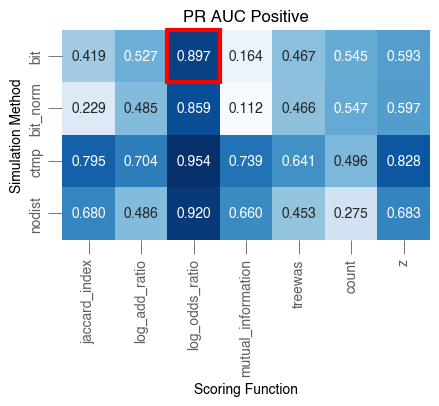

In [15]:
### Figure S2 (1/4)
plot_trav(pt_concat=pt_concat, metric="PR_AUC_Positive", es_input=1)

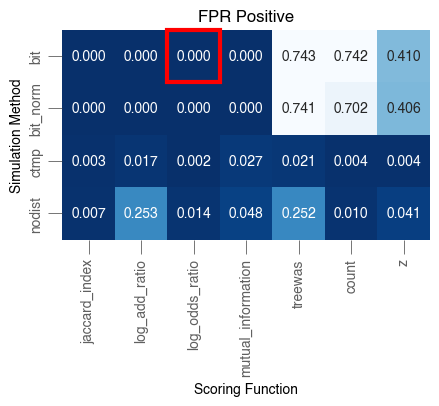

In [6]:
### Figure S2 (2/4)
plot_trav(pt_concat=pt_concat, metric="FPR_Positive", es_input=1.0, ascending=False)

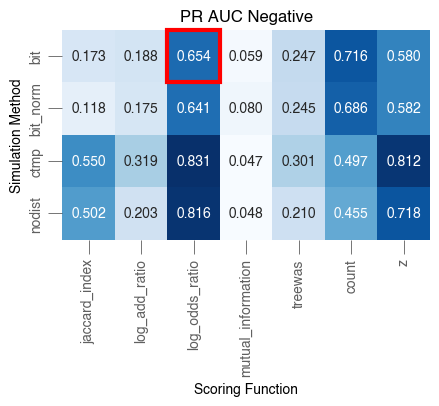

In [7]:
### Figure S2 (3/4)
plot_trav(pt_concat=pt_concat, metric="PR_AUC_Negative", es_input=1.0)

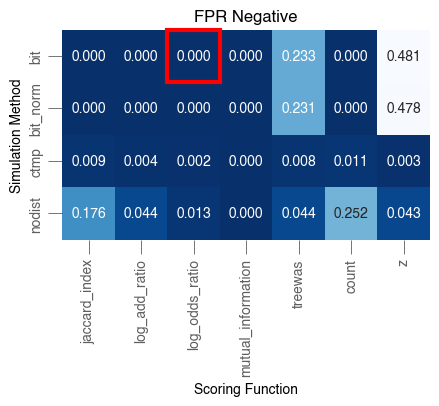

In [8]:
### Figure S2 (4/4)
plot_trav(pt_concat=pt_concat, metric="FPR_Negative", es_input=1.0, ascending=False)

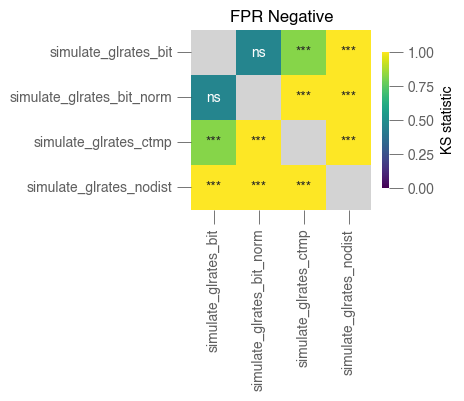

In [9]:
stat_name = "_log_odds_ratio_statistic"
value = 'FPR_Negative'
ks = test_metric(stat_name, value, es_input=1.0)
plot_ks(ks, value)

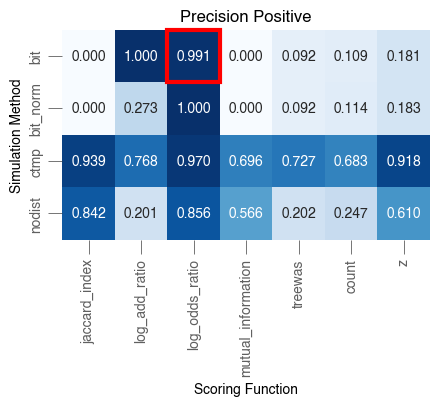

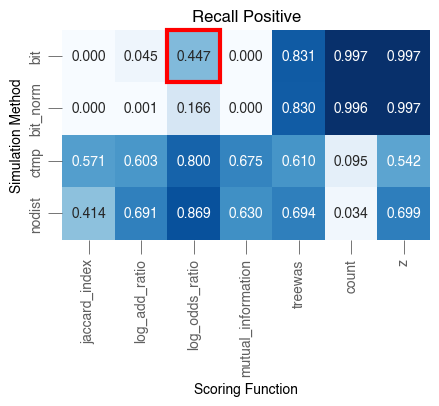

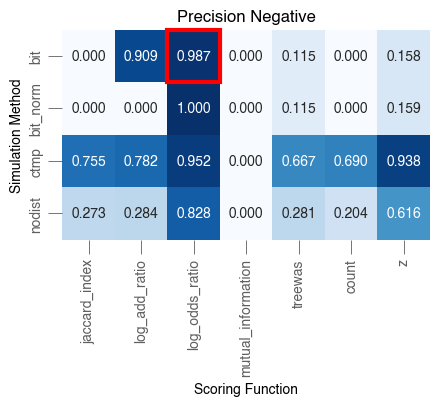

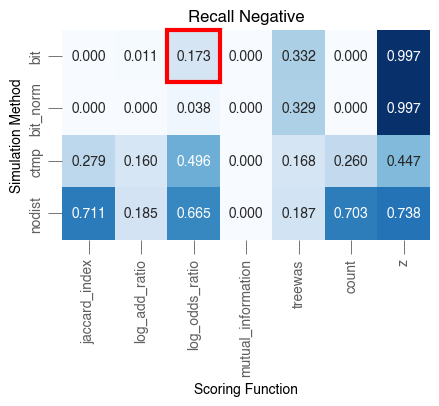

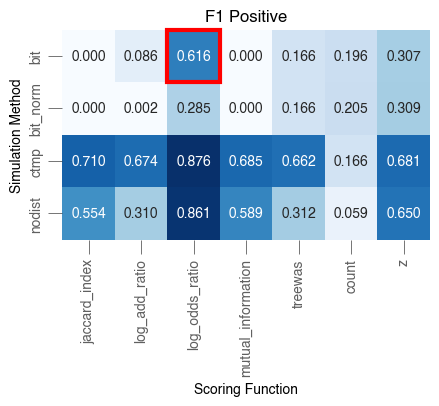

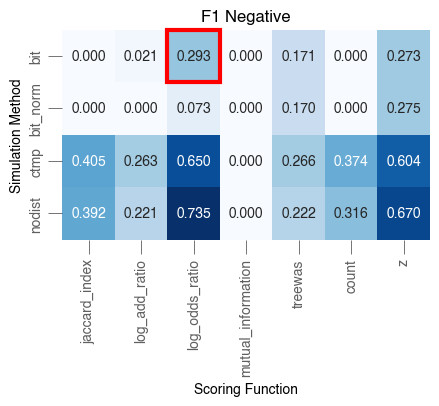

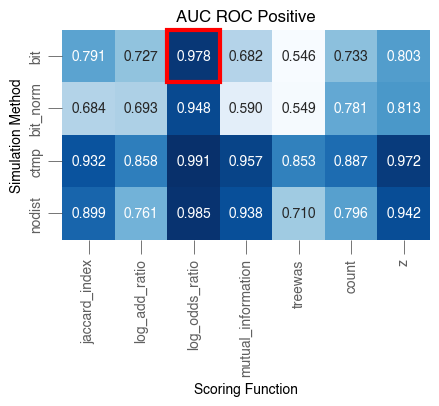

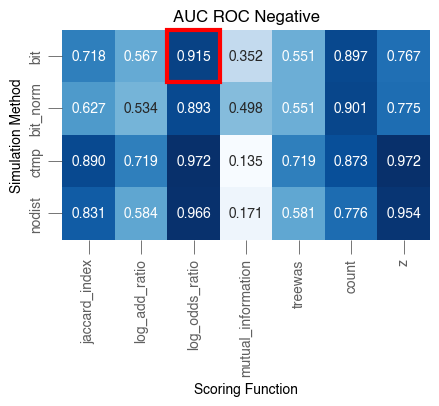

In [14]:
plot_trav(pt_concat, "Precision_Positive",  1.0)
plot_trav(pt_concat, "Recall_Positive",     1.0)
plot_trav(pt_concat, "Precision_Negative",  1.0)
plot_trav(pt_concat, "Recall_Negative",     1.0)
plot_trav(pt_concat, "F1_Positive",         1.0)
plot_trav(pt_concat, "F1_Negative",         1.0)
plot_trav(pt_concat, "AUC_ROC_Positive",    1.0)
plot_trav(pt_concat, "AUC_ROC_Negative",    1.0)

In [ ]:
def plot_trav_and_ks(pt_concat, metric, es_input,
                     stat_name="_log_odds_ratio_statistic",
                     ascending=True, counting_method='both'):
    """
    Side-by-side: traversal heatmap (left) + pairwise KS comparison (right).

    counting_method : 'joint' | 'flow' | 'both'
        'joint'/'flow' — single pair of panels for that counting method.
        'both' — two pairs of panels: JOINT (top) and FLOW (bottom).
    """
    has_counting = 'Counting' in pt_concat.columns

    # Determine which counting methods to render
    if counting_method == 'both' and has_counting:
        available = pt_concat['Counting'].unique()
        cms = [cm for cm in ['JOINT', 'FLOW'] if cm in available]
        if len(cms) < 2:
            counting_method = cms[0].lower() if cms else 'joint'

    def _render_one(df_in, counting_label):
        """Draw one traversal + KS pair, return figure."""
        if 'es_input' in df_in.columns:
            df_in = df_in[df_in['es_input'] == es_input]

        piv = pd.pivot_table(df_in, index='Method', columns='Statistic', values=metric)
        orig_index   = list(piv.index)
        orig_columns = list(piv.columns)
        piv.index   = [_rename_method(i)   for i in orig_index]
        piv.columns = [_clean_stat_name(c) for c in orig_columns]

        method_order  = list(piv.index)
        n             = len(method_order)
        stat_name_col = _clean_stat_name(stat_name)

        # KS matrix
        df_stat = df_in[df_in["Statistic"] == stat_name] if 'Statistic' in df_in.columns \
                  else df_in
        matrix_stat = pd.DataFrame(np.nan, index=method_order, columns=method_order)
        matrix_pval = pd.DataFrame(np.nan, index=method_order, columns=method_order)

        for m1, m2 in itertools.combinations(sorted(df_stat["Method"].unique()), 2):
            ks_stat, pval = ks_2samp(
                df_stat.loc[df_stat["Method"] == m1, metric],
                df_stat.loc[df_stat["Method"] == m2, metric],
            )
            lm1, lm2 = _rename_method(m1), _rename_method(m2)
            if lm1 in matrix_stat.index and lm2 in matrix_stat.columns:
                matrix_stat.loc[lm1, lm2] = matrix_stat.loc[lm2, lm1] = ks_stat
                matrix_pval.loc[lm1, lm2] = matrix_pval.loc[lm2, lm1] = pval

        def p_to_stars(p):
            if pd.isnull(p): return ""
            if p < 0.001: return "***"
            if p < 0.01:  return "**"
            if p < 0.05:  return "*"
            return "ns"

        annot_stars = matrix_pval.map(p_to_stars)
        mask = np.eye(n, dtype=bool)

        fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.5),
                                 gridspec_kw={"width_ratios": [1.35, 1]})

        ax0 = axes[0]
        sns.heatmap(piv, cmap='Blues' if ascending else 'Blues_r',
                    annot=True, fmt=".3f", cbar=False, square=True, ax=ax0)
        ax0.set_ylabel("Simulation Method")
        ax0.set_xlabel("Scoring Function")
        title = metric.replace('_', ' ')
        ax0.set_title(f"{title} — {counting_label}" if counting_label else title)
        ax0.set_xticklabels(ax0.get_xticklabels(), rotation=45, ha='right')

        if stat_name_col in list(piv.columns):
            col_idx = list(piv.columns).index(stat_name_col)
            ax0.add_patch(plt.Rectangle((col_idx, 0), 1, piv.shape[0],
                                        fill=False, lw=3, edgecolor='red', clip_on=False))

        ax1 = axes[1]
        sns.heatmap(matrix_stat.astype(float),
                    cmap=sns.color_palette("viridis", as_cmap=True),
                    annot=annot_stars, fmt="",
                    square=True, ax=ax1,
                    cbar_kws={"label": "KS statistic", "shrink": 0.6},
                    vmin=0, vmax=1, mask=mask, linewidths=0)

        for i in range(n):
            ax1.add_patch(plt.Rectangle((i, i), 1, 1, color="lightgrey", fill=True, lw=0))

        ax1.set_title(f"Statistical Comparison: {_clean_stat_name(stat_name).replace('_', ' ')}")
        ax1.set_ylabel("")
        ax1.set_yticks([])
        ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)

        plt.tight_layout()
        return fig

    if counting_method == 'both':
        figs = []
        for cm in ['JOINT', 'FLOW']:
            df_cm = pt_concat[pt_concat['Counting'] == cm] if has_counting else pt_concat
            figs.append(_render_one(df_cm, cm))
        plt.show()
        return figs
    else:
        cm = counting_method.upper()
        df_cm = pt_concat[pt_concat['Counting'] == cm] if has_counting else pt_concat
        fig = _render_one(df_cm, cm if has_counting else "")
        plt.show()
        return fig


es_input = 1.0   # es4
x = plot_trav_and_ks(pt_concat=pt_concat, metric="PR_AUC_Positive",  es_input=es_input)
x = plot_trav_and_ks(pt_concat=pt_concat, metric="PR_AUC_Negative",  es_input=es_input)
x = plot_trav_and_ks(pt_concat=pt_concat, metric="FPR_Positive",     es_input=es_input, ascending=False)
x = plot_trav_and_ks(pt_concat=pt_concat, metric="FPR_Negative",     es_input=es_input, ascending=False)